# Street-Level PM2.5 Estimation with XGBoost — Full Dataset
### Nested Spatial k-Fold Cross-Validation · Bayesian Hyperparameter Optimization · Spatial Bias Detection · SHAP Interpretability

This notebook implements the **XGBoost baseline model** described in Chapters 3–4 of the thesis
*"Estimating Street-Level PM2.5 Concentrations from Urban Morphology and Air Quality Sensor Networks"*
(Dela Cruz, Dizon, Dulatre, & Perez), using the **pilot testing subset** (19 sensors, 14 grid cells with enough history
after feature engineering).

**Pipeline:**
1. Data preparation & temporal feature engineering (`prep_n_proc_full.py`)
2. Spatial fold assignment via K-Means on grid-cell centroids (`spatial_cv.py`, unchanged)
3. Nested spatial k-Fold CV (outer k=4 / inner k=3) with Bayesian hyperparameter optimization
4. Spatial bias detection — Global & Local Moran's I (`spatial_bias.py`, unchanged)
5. Final production model + SHAP interpretability


## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import shap

from math import sqrt
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
np.random.seed(42)

MAPPING_CSV = 'sensor_to_grid_map_full.csv'  # written by prep_n_proc_full.py on import

print("xgboost:", xgb.__version__)


xgboost: 3.3.0


## 2. Data Preparation & Feature Engineering

Runs `prep_n_proc_full.py`, which:
- spatially joins the 18 sensors in `Master_DL_Ready.csv` to `full_morphology_grid.csv` and writes
  `sensor_to_grid_map_full.csv` (same schema as the pilot's mapping CSV)
- merges in morphology metrics + the derived `street_width_mean`
- engineers cyclical hour/day-of-week/month encodings
- computes gap-aware lags (1-4h) and rolling stats (24h, 72h) on a per-sensor hourly index
- log1p-transforms the target and drops rows whose lag/rolling window crosses a data gap


In [2]:
# prep_n_proc_full.py runs on import and defines: df_clean, X, y (log1p-transformed), features
import prep_n_proc_full as prep

df_clean = prep.df_clean
X, y, features = prep.X, prep.y, prep.features
groups = prep.groups

print(f"\nFeature matrix: X={X.shape}, y={y.shape} (log1p units)")
print(f"Unique Grid_IDs (spatial groups): {len(set(groups))}")
df_clean[['Location', 'Grid_ID', 'DateTime', 'Value'] + features].head()


Loading data...
Wrote sensor_to_grid_map_full.csv: 18 sensors -> 17 unique grid cells
Merging morphology metrics...
Engineering temporal features...
Computing time-aware lags & rolling stats (this replaces Master_DL_Ready.csv's own pm25_t-1/t-2/t-3, which are naive row-shifts -- see module docstring)...
Preparing model training...
Final matrix: X=(43273, 24), y=(43273,), unique groups=17

Feature matrix: X=(43273, 24), y=(43273,) (log1p units)
Unique Grid_IDs (spatial groups): 17


,Location,Grid_ID,DateTime,Value,bh_mean,bh_stdev,bldg_dens,ndvi_mean,aspect_ratio_mean,street_width_mean,...,pm25_lag_3,pm25_lag_4,pm25_diff_1_2,pm25_roll24_mean,pm25_roll24_std,pm25_roll72_mean,pm25_roll72_std,hour_x_bldg_dens,hour_x_ndvi,hour_x_aspect_ratio
0,4797640,81,2025-06-22 18:00:00+08:00,20.9,4.118918,3.926824,0.4804,0.152588,0.206025,19.992319,...,28.7,30.2,1.0,27.972083,12.830812,23.066667,11.917284,-0.480400,-0.152588,-0.206025
1,4797640,81,2025-06-22 19:00:00+08:00,17.1,4.118918,3.926824,0.4804,0.152588,0.206025,19.992319,...,21.5,28.7,-1.6,28.413750,12.370221,23.027273,11.810037,-0.464031,-0.147388,-0.199005
2,4797640,81,2025-06-22 20:00:00+08:00,17.9,4.118918,3.926824,0.4804,0.152588,0.206025,19.992319,...,22.5,21.5,-3.8,28.063750,12.573411,22.921429,11.728956,-0.416039,-0.132145,-0.178423
3,4797640,81,2025-06-22 21:00:00+08:00,40.9,4.118918,3.926824,0.4804,0.152588,0.206025,19.992319,...,20.9,22.5,0.8,27.776250,12.729205,22.833333,11.642774,-0.339694,-0.107896,-0.145682
4,4797640,81,2025-06-22 22:00:00+08:00,26.0,4.118918,3.926824,0.4804,0.152588,0.206025,19.992319,...,17.1,20.9,23.0,28.292917,13.008448,23.144828,11.781499,-0.240200,-0.076294,-0.103013


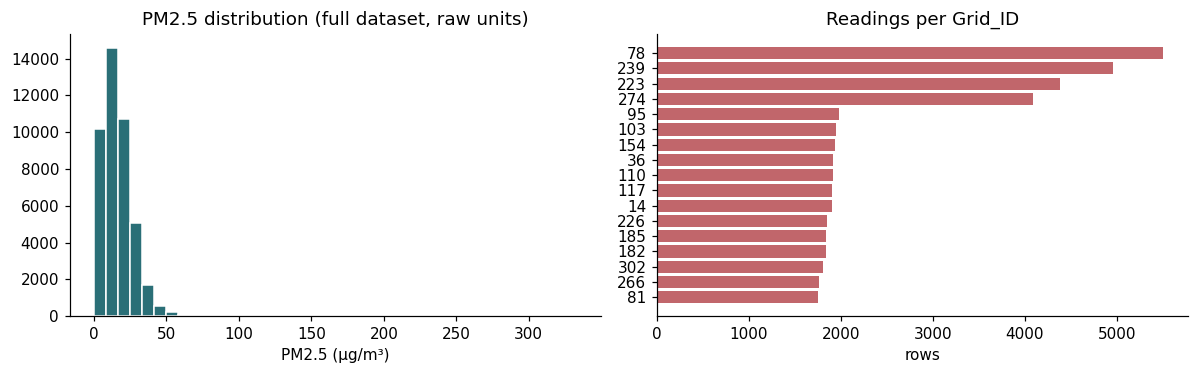

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(df_clean['Value'], bins=40, color='#2a6f77', edgecolor='white')
axes[0].set_title('PM2.5 distribution (full dataset, raw units)')
axes[0].set_xlabel('PM2.5 (\u00b5g/m\u00b3)')

rows_per_grid = df_clean['Grid_ID'].value_counts().sort_values()
axes[1].barh(rows_per_grid.index.astype(str), rows_per_grid.values, color='#c1666b')
axes[1].set_title('Readings per Grid_ID')
axes[1].set_xlabel('rows')

plt.tight_layout()
plt.show()


## 3. Spatial Fold Assignment

Per thesis Section 4.4.1, folds are assigned by **K-Means clustering the grid-cell centroids**.
`spatial_cv.py` is unchanged from the pilot notebook — it just now reads
`sensor_to_grid_map_full.csv` instead of `sensor_to_grid_map.csv`.


In [4]:
from spatial_cv import get_grid_centroids, assign_spatial_folds, get_outer_folds, get_inner_folds

outer_fold_map = get_outer_folds(MAPPING_CSV, k=4, random_state=42)
df_clean['outer_fold'] = df_clean['Grid_ID'].map(outer_fold_map)

print("Outer fold sizes (rows):")
print(df_clean['outer_fold'].value_counts().sort_index())


Outer fold sizes (rows):
outer_fold
0    14984
1     5420
2     5770
3    17099
Name: count, dtype: int64


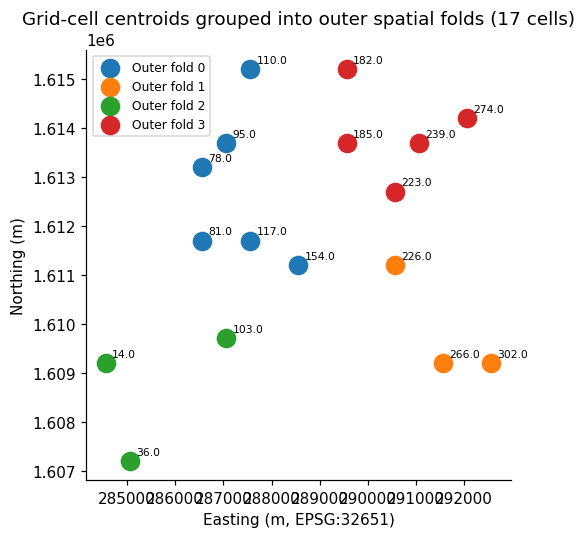

In [5]:
centroids = get_grid_centroids(MAPPING_CSV)
centroids_plot = assign_spatial_folds(centroids, k=4, random_state=42)

plt.figure(figsize=(5, 5))
for f in sorted(centroids_plot['fold'].unique()):
    sub = centroids_plot[centroids_plot['fold'] == f]
    plt.scatter(sub['cx'], sub['cy'], s=140, label=f'Outer fold {f}')
for _, r in centroids_plot.iterrows():
    plt.annotate(str(r['Grid_ID']), (r['cx'], r['cy']), fontsize=7,
                 xytext=(4, 4), textcoords='offset points')
plt.title('Grid-cell centroids grouped into outer spatial folds (17 cells)')
plt.xlabel('Easting (m, EPSG:32651)'); plt.ylabel('Northing (m)')
plt.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 4. Nested Spatial k-Fold CV with Bayesian Hyperparameter Optimization

Same search space and nested outer(k=4)/inner(k=3) structure as the pilot notebook. The only
functional difference is that RMSE/MAE/R² are computed after inverse-transforming predictions
(`np.expm1`) back to raw PM2.5 units, since `y` here is log1p-transformed.


In [6]:
N_TRIALS = 20  # Bayesian optimization calls per outer fold

SEARCH_SPACE = [
    Integer(2, 5,      name='max_depth'),
    Integer(1, 15,     name='min_child_weight'),
    Real(0.5, 1.0,     name='subsample'),
    Real(0.5, 1.0,     name='colsample_bytree'),
    Real(0.01, 0.3,    name='learning_rate', prior='log-uniform'),
    Real(0.0, 5.0,     name='gamma'),
    Real(0.1, 10.0,    name='reg_lambda', prior='log-uniform'),
    Real(0.0, 10.0,    name='reg_alpha'),
]

fold_results = []
oof_records = []

for outer_f in sorted(df_clean['outer_fold'].unique()):
    print(f"\n--- Outer fold {outer_f} ---")

    train_mask = (df_clean['outer_fold'] != outer_f).values
    test_mask  = (df_clean['outer_fold'] == outer_f).values
    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    held_out_grid_ids = df_clean.loc[test_mask, 'Grid_ID'].unique()
    inner_fold_map = get_inner_folds(MAPPING_CSV, exclude_grid_ids=held_out_grid_ids,
                                      k=3, random_state=42)
    inner_fold_labels = df_clean.loc[train_mask, 'Grid_ID'].map(inner_fold_map).values
    call_records = []

    @use_named_args(SEARCH_SPACE)
    def objective(**params):
        inner_rmses, best_iters = [], []
        for inner_f in sorted(set(inner_fold_labels)):
            itr = inner_fold_labels != inner_f
            ite = inner_fold_labels == inner_f

            model = xgb.XGBRegressor(n_estimators=500, early_stopping_rounds=20,
                                      random_state=42, **params)
            model.fit(X_train[itr], y_train[itr],
                      eval_set=[(X_train[ite], y_train[ite])], verbose=False)

            preds = model.predict(X_train[ite])
            # inner-loop model selection stays in log1p units (monotonic transform, same ranking)
            inner_rmses.append(sqrt(mean_squared_error(y_train[ite], preds)))
            best_iters.append(model.best_iteration)

        avg_rmse = float(np.mean(inner_rmses))
        call_records.append({'params': params, 'avg_rmse': avg_rmse,
                              'avg_best_iteration': float(np.mean(best_iters))})
        return avg_rmse

    result = gp_minimize(objective, SEARCH_SPACE, n_calls=N_TRIALS,
                          n_initial_points=8, random_state=42, verbose=False)

    best_call = min(call_records, key=lambda r: r['avg_rmse'])
    best_params = best_call['params']
    best_n_estimators = max(10, round(best_call['avg_best_iteration']))
    print(f"Best inner-CV RMSE (log1p units): {best_call['avg_rmse']:.3f} | n_estimators={best_n_estimators}")
    print(f"Best params: {best_params}")

    final_model = xgb.XGBRegressor(n_estimators=best_n_estimators, random_state=42, **best_params)
    final_model.fit(X_train, y_train)

    preds_test_raw = np.expm1(final_model.predict(X_test))
    y_test_raw = np.expm1(y_test)
    rmse = sqrt(mean_squared_error(y_test_raw, preds_test_raw))
    mae = mean_absolute_error(y_test_raw, preds_test_raw)
    r2 = r2_score(y_test_raw, preds_test_raw)
    print(f"Outer-test  RMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}  (n={test_mask.sum()})")

    fold_results.append({
        'outer_fold': outer_f, 'n_test_rows': int(test_mask.sum()),
        'rmse': rmse, 'mae': mae, 'r2': r2,
        'best_params': best_params, 'n_estimators': best_n_estimators,
    })

    oof_chunk = df_clean.loc[test_mask, ['Location', 'Grid_ID', 'DateTime', 'Value']].copy()
    oof_chunk['predicted'] = preds_test_raw
    oof_chunk['residual'] = oof_chunk['predicted'] - oof_chunk['Value']
    oof_chunk['outer_fold'] = outer_f
    oof_records.append(oof_chunk)

results_df = pd.DataFrame(fold_results)
oof_df = pd.concat(oof_records, ignore_index=True)



--- Outer fold 0 ---
Best inner-CV RMSE (log1p units): 0.386 | n_estimators=258
Best params: {'max_depth': np.int64(5), 'min_child_weight': np.int64(6), 'subsample': 0.5224049876588478, 'colsample_bytree': 0.5135918936510218, 'learning_rate': 0.03431595715102913, 'gamma': 0.0030134754440830362, 'reg_lambda': 0.1981605753045257, 'reg_alpha': 1.0953465912305862}
Outer-test  RMSE=6.935  MAE=4.266  R2=0.617  (n=14984)

--- Outer fold 1 ---
Best inner-CV RMSE (log1p units): 0.382 | n_estimators=471
Best params: {'max_depth': np.int64(5), 'min_child_weight': np.int64(5), 'subsample': 0.9800778608791053, 'colsample_bytree': 0.7870970891799258, 'learning_rate': 0.02722786282361807, 'gamma': 0.0, 'reg_lambda': 0.6771459850071259, 'reg_alpha': 6.760163028684608}
Outer-test  RMSE=7.970  MAE=4.974  R2=0.655  (n=5420)

--- Outer fold 2 ---
Best inner-CV RMSE (log1p units): 0.370 | n_estimators=195
Best params: {'max_depth': np.int64(5), 'min_child_weight': np.int64(11), 'subsample': 0.546307334102

## 5. Nested CV Results

In [7]:
print("=== Nested spatial CV summary ===")
display_cols = ['outer_fold', 'n_test_rows', 'rmse', 'mae', 'r2']
print(results_df[display_cols].round(3).to_string(index=False))

print(f"\nMean RMSE: {results_df['rmse'].mean():.3f}  (+/- {results_df['rmse'].std():.3f})")
print(f"Mean MAE:  {results_df['mae'].mean():.3f}  (+/- {results_df['mae'].std():.3f})")
print(f"Mean R2:   {results_df['r2'].mean():.3f}  (+/- {results_df['r2'].std():.3f})")

pooled_rmse = sqrt(mean_squared_error(oof_df['Value'], oof_df['predicted']))
pooled_mae = mean_absolute_error(oof_df['Value'], oof_df['predicted'])
pooled_r2 = r2_score(oof_df['Value'], oof_df['predicted'])
print(f"\nPooled out-of-fold (all folds combined): RMSE={pooled_rmse:.3f}  MAE={pooled_mae:.3f}  R2={pooled_r2:.3f}")


=== Nested spatial CV summary ===
 outer_fold  n_test_rows  rmse   mae    r2
          0        14984 6.935 4.266 0.617
          1         5420 7.970 4.974 0.655
          2         5770 7.568 4.473 0.615
          3        17099 6.252 3.389 0.625

Mean RMSE: 7.182  (+/- 0.752)
Mean MAE:  4.276  (+/- 0.661)
Mean R2:   0.628  (+/- 0.018)

Pooled out-of-fold (all folds combined): RMSE=6.906  MAE=4.036  R2=0.631


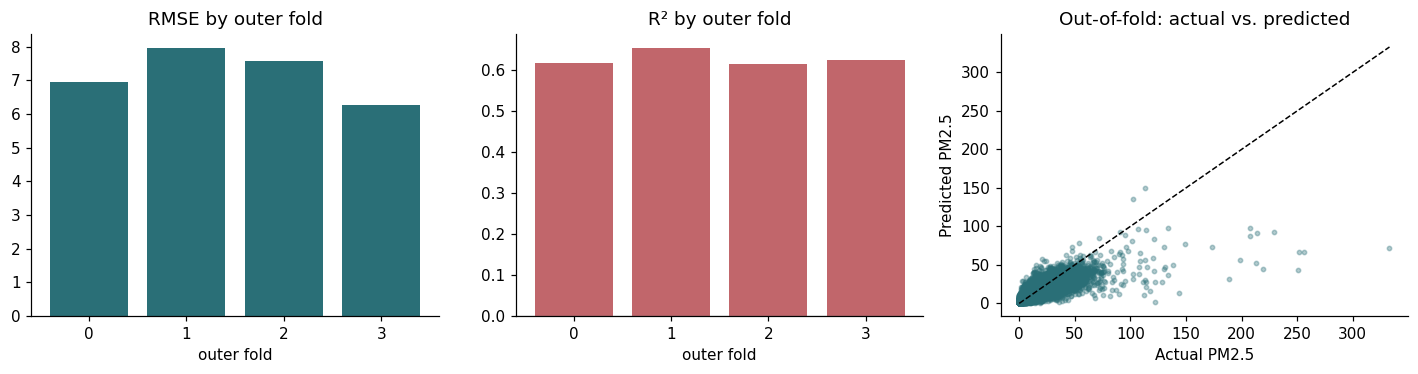

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].bar(results_df['outer_fold'].astype(str), results_df['rmse'], color='#2a6f77')
axes[0].set_title('RMSE by outer fold'); axes[0].set_xlabel('outer fold')

axes[1].bar(results_df['outer_fold'].astype(str), results_df['r2'], color='#c1666b')
axes[1].set_title('R\u00b2 by outer fold'); axes[1].set_xlabel('outer fold')
axes[1].axhline(0, color='gray', linewidth=0.8)

axes[2].scatter(oof_df['Value'], oof_df['predicted'], s=8, alpha=0.35, color='#2a6f77')
lims = [oof_df[['Value', 'predicted']].min().min(), oof_df[['Value', 'predicted']].max().max()]
axes[2].plot(lims, lims, 'k--', linewidth=1)
axes[2].set_title('Out-of-fold: actual vs. predicted')
axes[2].set_xlabel('Actual PM2.5'); axes[2].set_ylabel('Predicted PM2.5')

plt.tight_layout(); plt.show()


## 6. Spatial Bias Detection (Section 4.4.3)

`spatial_bias.py` is unchanged — it just reads `sensor_to_grid_map_full.csv`.


In [9]:
from spatial_bias import aggregate_residuals_by_grid, build_knn_weights, global_morans_i, local_morans_i

grid_residuals = aggregate_residuals_by_grid(oof_df, MAPPING_CSV)
print(f"Aggregated to {len(grid_residuals)} grid cells (mean OOF residual per cell):")
print(grid_residuals[['Grid_ID', 'residual']].sort_values('residual').to_string(index=False))

w = build_knn_weights(grid_residuals, k=4)
I, p_value = global_morans_i(grid_residuals['residual'].values, w)
print(f"\nGlobal Moran's I: {I:.3f}  (p = {p_value:.3f})")

if p_value < 0.05:
    direction = "positive (residuals of similar sign/magnitude cluster together)" if I > 0 \
        else "negative (dispersed/checkerboard pattern)"
    print(f"-> Statistically significant spatial clustering detected: {direction}")
    lisa_df = local_morans_i(grid_residuals['residual'].values, w)
    lisa_df = pd.concat([grid_residuals[['Grid_ID', 'residual']].reset_index(drop=True), lisa_df], axis=1)
    print(lisa_df.sort_values('p_sim').to_string(index=False))
else:
    print("-> No statistically significant spatial pattern in residuals "
          "(errors appear geographically random at this alpha).")


Aggregated to 17 grid cells (mean OOF residual per cell):
 Grid_ID  residual
      14 -2.346864
     226 -1.962494
     302 -1.834020
     223 -1.651821
      81 -1.394697
     182 -1.311803
      78 -1.265340
      95 -1.046603
     185 -0.993191
     266 -0.979084
     117 -0.977065
     110 -0.654526
     154 -0.634652
     239 -0.623769
      36 -0.490244
     103 -0.465681
     274  0.160786

Global Moran's I: -0.153  (p = 0.360)
-> No statistically significant spatial pattern in residuals (errors appear geographically random at this alpha).


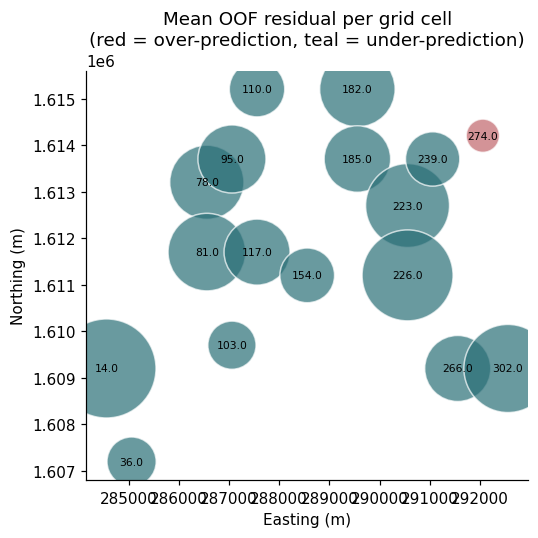

In [10]:
plt.figure(figsize=(5, 5))
sizes = 200 + 4000 * (grid_residuals['residual'].abs() / grid_residuals['residual'].abs().max())
colors = np.where(grid_residuals['residual'] >= 0, '#c1666b', '#2a6f77')
plt.scatter(grid_residuals['cx'], grid_residuals['cy'], s=sizes, c=colors, alpha=0.7, edgecolor='white')
for _, r in grid_residuals.iterrows():
    plt.annotate(str(r['Grid_ID']), (r['cx'], r['cy']), fontsize=7,
                 ha='center', va='center')
plt.title("Mean OOF residual per grid cell\n(red = over-prediction, teal = under-prediction)")
plt.xlabel('Easting (m)'); plt.ylabel('Northing (m)')
plt.tight_layout(); plt.show()


## 7. Final Production Model

Same approach as the pilot notebook: one more spatial (k=4) hyperparameter search using **all**
the data, then a final fit with the winning configuration.


In [11]:
final_fold_map = get_outer_folds(MAPPING_CSV, k=4, random_state=7)  # different seed than the nested-CV search above
final_fold_labels = df_clean['Grid_ID'].map(final_fold_map).values

final_call_records = []

@use_named_args(SEARCH_SPACE)
def final_objective(**params):
    rmses, best_iters = [], []
    for f in sorted(set(final_fold_labels)):
        tr = final_fold_labels != f
        te = final_fold_labels == f
        model = xgb.XGBRegressor(n_estimators=500, early_stopping_rounds=20, random_state=42, **params)
        model.fit(X[tr], y[tr], eval_set=[(X[te], y[te])], verbose=False)
        preds = model.predict(X[te])
        rmses.append(sqrt(mean_squared_error(y[te], preds)))
        best_iters.append(model.best_iteration)
    avg_rmse = float(np.mean(rmses))
    final_call_records.append({'params': params, 'avg_rmse': avg_rmse,
                                'avg_best_iteration': float(np.mean(best_iters))})
    return avg_rmse

final_result = gp_minimize(final_objective, SEARCH_SPACE, n_calls=N_TRIALS,
                            n_initial_points=8, random_state=42, verbose=False)

final_best = min(final_call_records, key=lambda r: r['avg_rmse'])
final_n_estimators = max(10, round(final_best['avg_best_iteration']))
print(f"Production model params: {final_best['params']}")
print(f"Production n_estimators: {final_n_estimators}")

production_model = xgb.XGBRegressor(n_estimators=final_n_estimators, random_state=42, **final_best['params'])
production_model.fit(X, y)
print("Production model fit on the full dataset.")


Production model params: {'max_depth': np.int64(5), 'min_child_weight': np.int64(1), 'subsample': 1.0, 'colsample_bytree': 1.0, 'learning_rate': 0.042828784991065655, 'gamma': 0.0, 'reg_lambda': 10.0, 'reg_alpha': 0.0}
Production n_estimators: 354
Production model fit on the full dataset.


## 8. Feature Importance & SHAP Interpretability (Section 4.5.4)

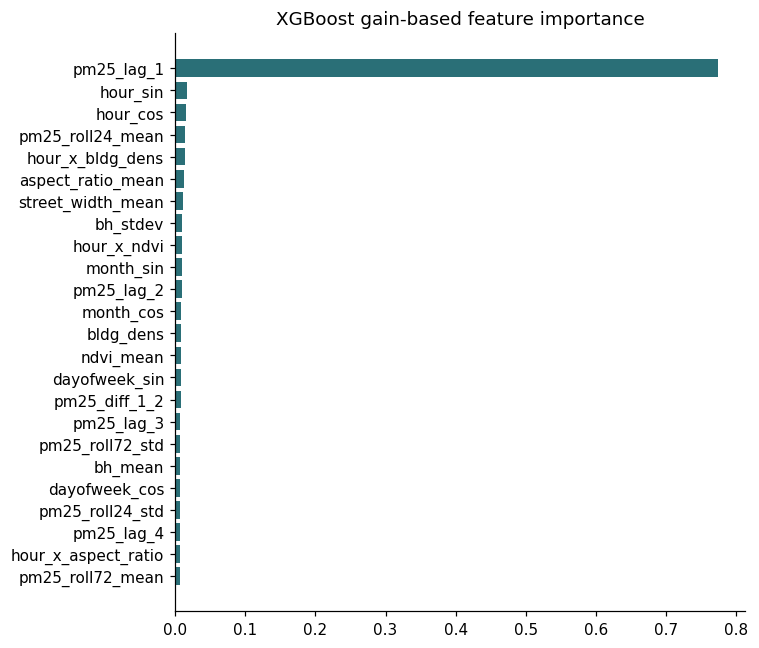

In [12]:
importances = pd.Series(production_model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(7, 6))
plt.barh(importances.index, importances.values, color='#2a6f77')
plt.title('XGBoost gain-based feature importance')
plt.tight_layout(); plt.show()


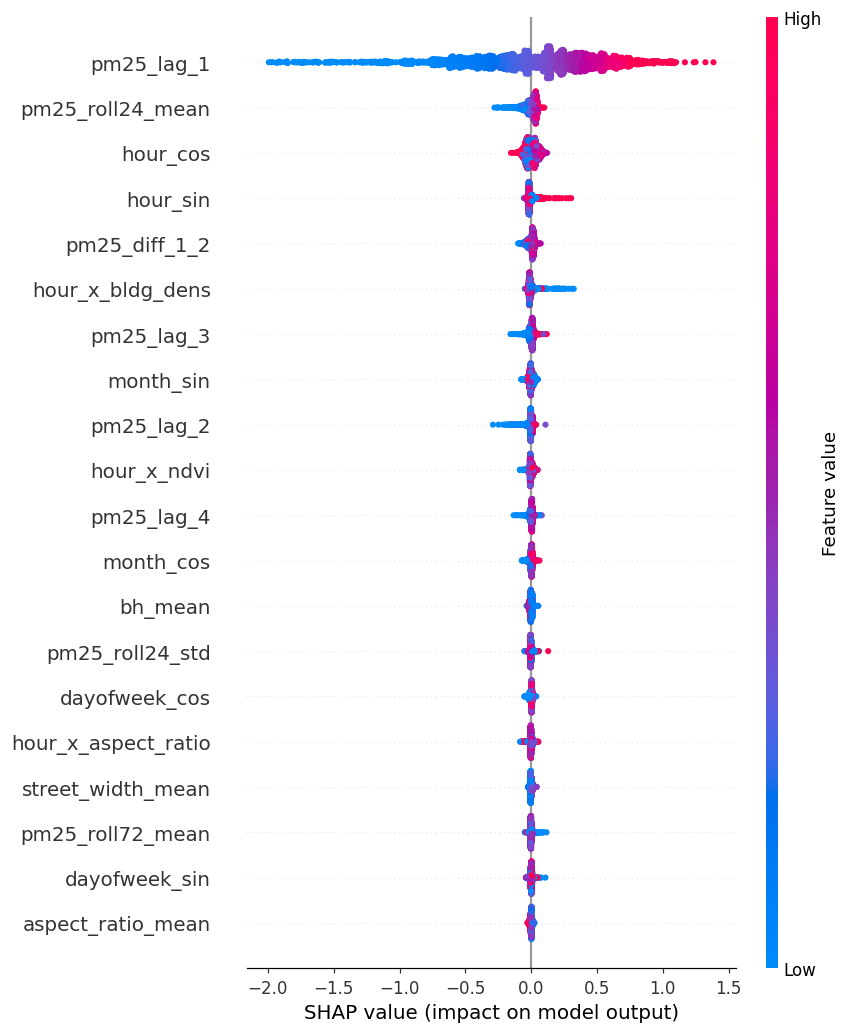

In [13]:
explainer = shap.TreeExplainer(production_model)
X_sample = X if X.shape[0] <= 3000 else X[np.random.choice(X.shape[0], 3000, replace=False)]
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, feature_names=features, show=False)
plt.tight_layout(); plt.show()


In [14]:
morphology_features = ['bh_mean', 'bh_stdev', 'bldg_dens', 'ndvi_mean',
                       'aspect_ratio_mean', 'street_width_mean']
shap_df = pd.DataFrame(shap_values, columns=features)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

print("Mean |SHAP value| per feature (log1p-target units):")
print(mean_abs_shap.round(3).to_string())

morph_share = mean_abs_shap[morphology_features].sum() / mean_abs_shap.sum()
print(f"\nShare of total |SHAP| attributable to urban-morphology features: {morph_share:.1%}")


Mean |SHAP value| per feature (log1p-target units):
pm25_lag_1             0.415
pm25_roll24_mean       0.035
hour_cos               0.032
hour_sin               0.021
pm25_diff_1_2          0.018
hour_x_bldg_dens       0.015
pm25_lag_3             0.014
month_sin              0.012
pm25_lag_2             0.012
hour_x_ndvi            0.010
pm25_lag_4             0.009
month_cos              0.008
bh_mean                0.007
pm25_roll24_std        0.006
dayofweek_cos          0.006
hour_x_aspect_ratio    0.006
street_width_mean      0.006
pm25_roll72_mean       0.005
dayofweek_sin          0.005
aspect_ratio_mean      0.004
pm25_roll72_std        0.004
bldg_dens              0.003
ndvi_mean              0.003
bh_stdev               0.000

Share of total |SHAP| attributable to urban-morphology features: 3.5%


## 9. Summary

- **18 sensors / 17 grid cells / ~43k rows** after gap-aware lag cleaning (vs. the pilot's 19
  sensors / 14 cells / ~14.6k rows) — a real increase in both spatial and temporal coverage,
  though smaller than the "46-sensor" figure floated earlier once the actual `Master_DL_Ready.csv`
  was checked (it holds 18 sensors that survived the CNN-LSTM branch's own spatial + data-quality
  filtering, not 46).
- **Nested spatial CV** (outer k=4, inner k=3) gives an unbiased read on generalization to unseen
  grid cells, same as the pilot, now on the larger dataset.
- **A genuine data bug was found and fixed**: `Master_DL_Ready.csv`'s built-in `pm25_t-1/t-2/t-3`
  columns mislabel readings during timestamp gaps (confirmed directly on the raw data). Recomputing
  them time-aware, rather than reusing them, avoids quietly feeding the model wrong lag values.
- **`street_width_mean` was added** to actually complete the paper's declared 8-feature list
  (previously missing from the feature matrix entirely).
- **Spatial-lag (neighbor-cell) features were deliberately left out**, since they'd conflict with
  the paper's stated design of scoping predictors to each sensor's own buffer.
- Compare `results_df['r2'].mean()` here against the CNN-LSTM's spatial-CV R² directly — both now
  run on the same 18-sensor data, so the comparison means what it looks like it means.
